In [2]:
import sys
sys.path.append('../')

In [3]:
import Hamiltonian as ham
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol
from run_qite import run_QITE,get_statevector,build_acq_circuit_qrisp

from qrisp import QuantumVariable
from qrisp.vqe import VQEProblem
from qrisp.vqe.problems.heisenberg import create_heisenberg_init_function
from qrisp.operators import X, Y, Z
import networkx as nx

import importlib
importlib.reload(ham)

/home/luca/Documents/QITE-UV/Qite/lib/python3.12/site-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


<module 'Hamiltonian' from '/home/luca/Documents/ACQ/DBF/../Hamiltonian.py'>

In [4]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def variance(psi,H):
    V=np.real((psi.conj().T@H@H@psi)-(psi.conj().T@H@psi)**2)
    return V[0,0]


In [5]:
L = 6
G = nx.Graph()
G.add_edges_from([(k, (k+1)%L) for k in range(L-1)]) 
# nx.draw(G, with_labels=True)

H = sum((X(i)*X(j)+Y(i)*Y(j)+Z(i)*Z(j)) for i,j in G.edges())
H_acq,H_trot_acq = ham.Heisenberg(1,L)
print(np.all(H_acq.toarray() == H.to_array()))

print('Computing Eigs')
EH,VH = np.linalg.eigh(H.to_array())
psigs=VH[:,0:1]
E_gs=EH[0]


Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 5 terms with the starting qubit of each piece at [0, 1, 2, 3, 4]
True
Computing Eigs


In [6]:
# Define scaling factor
alpha = 10

# Hamiltonian simulation via second order Suzuki-Trotter formula with 2 steps
def exp_H(qv, t):
    H.trotterization(order=2, method='commuting')(qv, t/alpha, 2)

In [7]:
# Tensor product of singlet states
M = nx.maximal_matching(G)
U_singlet = create_heisenberg_init_function(M)

# HVA
H0 = sum((X(i)*X(j)+Y(i)*Y(j)+Z(i)*Z(j)) for i,j in M)
H1 = sum((X(i)*X(j)+Y(i)*Y(j)+Z(i)*Z(j)) for i,j in set(G.edges())-M)

def ansatz(qv, theta):
    # Rescaling t->1/4 equivalent to choosing rescaled inital parameters for HVA
    H1.trotterization(method='commuting')(qv, t=theta[1]/4)
    H0.trotterization(method='commuting')(qv, t=theta[0]/4)

HVA = VQEProblem(H, ansatz, 2, init_function=U_singlet)
U_HVA = HVA.train_function(QuantumVariable(G.number_of_nodes()), depth=1, max_iter=100)

# Calculate energy for HVA
def state_prep_hva():
    qv = QuantumVariable(L)
    U_HVA(qv)
    return qv

def state_prep_singlet():
    qv = QuantumVariable(L)
    U_singlet(qv)
    return qv


Simulating 6 qubits.. |                                                 | [  0%]

In [ ]:
steps=5
results = []

results.append(run_QITE(H, U_singlet, exp_H, np.linspace(.01,1.5,20), steps, method='GC', use_statevectors=True))
results.append(run_QITE(H, U_HVA, exp_H, np.linspace(.01,1.5,20), steps, method='GC', use_statevectors=True))

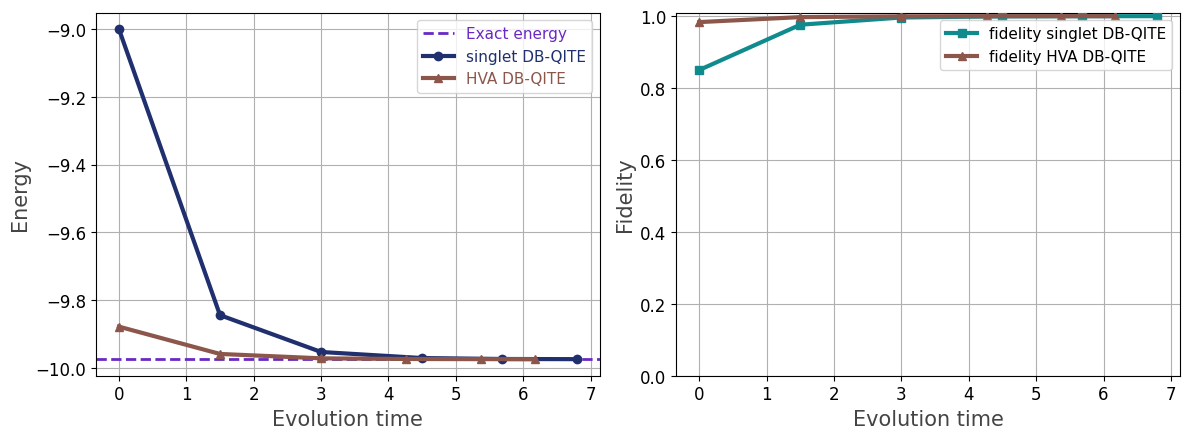

In [41]:
import matplotlib.pyplot as plt
import numpy as np

fidelities_singlet = [fidelity_pure(psigs, results[0]['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]
fidelities_HVA = [fidelity_pure(psigs, results[1]['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Energy plot
ax1.set_xlabel('Evolution time', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(results[0]['evolution_times'], results[0]['optimal_energies'], c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='singlet DB-QITE')
ax1.plot(results[1]['evolution_times'], results[1]['optimal_energies'], c='#8c564b', marker='^', linestyle='solid', linewidth=3, zorder=3, label='HVA DB-QITE')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('Evolution time', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(results[0]['evolution_times'], fidelities_singlet, c='#0f8b8d', marker='s', linestyle='solid', linewidth=3, zorder=3, label='fidelity singlet DB-QITE')
ax2.plot(results[1]['evolution_times'], fidelities_HVA, c='#8c564b', marker='^', linestyle='solid', linewidth=3, zorder=3, label='fidelity HVA DB-QITE')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

#plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps}_DBF_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [43]:
results[0]['circuit_data'], results[1]['circuit_data']

([{0: {'u3': 9, 'cz': 3},
   1: {'u3': 223, 'cz': 117},
   2: {'u3': 802, 'cz': 435},
   3: {'u3': 2359, 'cz': 1299},
   4: {'u3': 7042, 'cz': 3897},
   5: {'u3': 21271, 'cz': 11781}},
  {0: 6, 1: 8, 2: 8, 3: 8, 4: 8, 5: 8},
  {0: 3, 1: 131, 2: 491, 3: 1499, 4: 4529, 5: 13691}],
 [{0: {'u3': 42, 'cz': 18},
   1: {'u3': 313, 'cz': 162},
   2: {'u3': 1072, 'cz': 570},
   3: {'u3': 3181, 'cz': 1710},
   4: {'u3': 9688, 'cz': 5220},
   5: {'u3': 29209, 'cz': 15750}},
  {0: 6, 1: 8, 2: 8, 3: 8, 4: 8, 5: 8},
  {0: 15, 1: 167, 2: 599, 3: 1829, 4: 5591, 5: 16877}])

In [29]:
qc_singlet = state_prep_singlet().qs.compile()
qc_hva = state_prep_hva().qs.compile()
psi_0_singlet = sp.csc_matrix(np.real_if_close(get_statevector(qc_singlet,L).reshape(-1,1)))
psi_0_hva = sp.csc_matrix(get_statevector(qc_hva,L).reshape(-1,1))

#ACQ evolution
D=4
dt = 0.05
N = 100
print("Computing ACQ")
E_ACQ_singlet,psi_ACQ_singlet,indx_acq_singlet,times_acq_singlet,a_acq_singlet = evol.ACQ(L,H_acq,H_trot_acq,D,psi_0_singlet,N,dt,methodLS='LU')
E_ACQ_hva,psi_ACQ_hva,indx_acq_hva,times_acq_hva,a_acq_hva = evol.ACQ(L,H_acq,H_trot_acq,D,psi_0_hva,N,dt,methodLS='LU')


Simulating 6 qubits.. |                                                 | [  0%]

Computing ACQ                                                                   
Using Real Pauli Strings
Computing U at step 0
Computing U at step 4
Computing U at step 6
Energy doubly increased, stopping criteria activated at step 7
Using General Pauli Strings
Computing U at step 0
Computing U at step 2
Computing U at step 3
Computing U at step 4
Energy doubly increased, stopping criteria activated at step 5


In [31]:
import PauliStrings as ps
from run_qite import build_acq_circuit_qrisp

num_paulis,PD,fail = ps.real(H_trot_acq,D,L,PDstr=True)
circuit_ops_singlet = {}
circuits_singlet = {}
circuit_ops_hva = {}
circuits_hva = {}
steps_acq_hva = len(a_acq_hva)
steps_acq_singlet = len(a_acq_singlet)

for step in range(steps_acq_singlet+1): 
    qc_singlet = build_acq_circuit_qrisp(L,D,2,PD,a_acq_singlet,times_acq_singlet,step,U_singlet,atol=1e-5,alpha=10,trotter_steps=2)
    tqc_singlet = qc_singlet.transpile(basis_gates=['cz','u'])

    circuits_singlet[step] = qc_singlet
    circuit_ops_singlet[step] = tqc_singlet.count_ops()

for step in range(steps_acq_hva+1):
    qc_hva = build_acq_circuit_qrisp(L,D,2,PD,a_acq_hva,times_acq_hva,step,U_HVA,atol=1e-5,alpha=10,trotter_steps=2)
    tqc_hva = qc_hva.transpile(basis_gates=['cz','u'])

    circuits_hva[step] = qc_hva
    circuit_ops_hva[step] = tqc_hva.count_ops()

results_acq = {
    'singlet': {
        'circuit_data': circuit_ops_singlet,
        'circuits': circuits_singlet
    },
    'HVA': {
        'circuit_data': circuit_ops_hva,
        'circuits': circuits_hva
    }
}


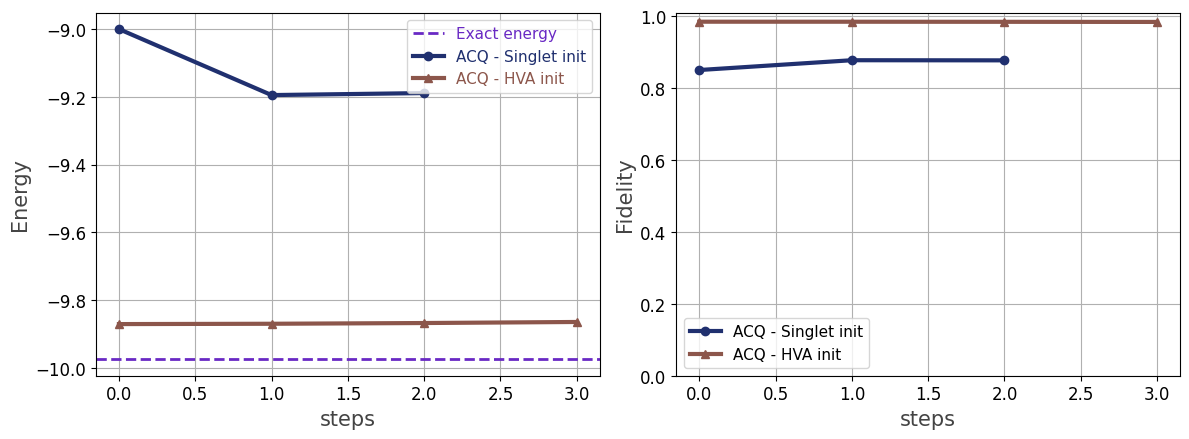

In [32]:
from run_qite import get_statevector,compute_moments

energies_acq_singlet = [compute_moments(get_statevector(results_acq['singlet']['circuits'][step],L),H_acq)[0] for step in range(steps_acq_singlet+1)]
fidelities_acq_singlet = [fidelity_pure(psigs, get_statevector(results_acq['singlet']['circuits'][step],L).reshape(-1,1)) for step in range(steps_acq_singlet+1)]

energies_acq_hva = [compute_moments(get_statevector(results_acq['HVA']['circuits'][step],L),H_acq)[0] for step in range(steps_acq_hva+1)]
fidelities_acq_hva = [fidelity_pure(psigs, get_statevector(results_acq['HVA']['circuits'][step],L).reshape(-1,1)) for step in range(steps_acq_hva+1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Energy plot
ax1.set_xlabel('steps', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(range(steps_acq_singlet+1), energies_acq_singlet, c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ - Singlet init')
ax1.plot(range(steps_acq_hva+1), energies_acq_hva, c='#8c564b', marker='^', linestyle='solid', linewidth=3, zorder=3, label='ACQ - HVA init')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('steps', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(range(steps_acq_singlet+1), fidelities_acq_singlet, c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ - Singlet init')
ax2.plot(range(steps_acq_hva+1), fidelities_acq_hva, c='#8c564b', marker='^', linestyle='solid', linewidth=3, zorder=3, label='ACQ - HVA init')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11, loc='upper right')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

#plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps_acq}_ACQ_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [33]:
results_acq['singlet']['circuit_data'], results_acq['HVA']['circuit_data']

({0: {'u3': 9, 'cz': 3}, 1: {'u3': 244, 'cz': 201}, 2: {'u3': 727, 'cz': 705}},
 {0: {'u3': 42, 'cz': 18},
  1: {'u3': 689, 'cz': 648},
  2: {'u3': 1324, 'cz': 1264},
  3: {'u3': 1961, 'cz': 1894}})

In [35]:
a_acq_hva

[array([[-2.32012601e-07+1.66411726e-07j,  0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
          0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         -8.16604282e-08+6.99995620e-08j],
        [ 8.69598735e-07+1.01653373e-09j,  0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
          0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         -1.03876276e-06+2.96060647e-07j],
        [-4.82119660e-09-7.37057323e-10j,  0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
          0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
          4.32093826e-08+1.19770599e-07j],
        [ 1.78337399e-07-3.03986594e-07j,  0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
          0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
          4.83943728e-08-2.14598359e-07j],
        [ 5.83286053e-08+3.98295761e-08j